# Multivariate Data Analysis
In this notebook, we analyze the relationships between multiple features simultaneously. Our primary goal is to understand how different predictor variables interact with each other and, more importantly, how they influence our target variable, `tip`. This will guide our feature selection for the final model.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
sns.set_theme(style='darkgrid')

In [34]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# Goal
To visualize the relationship between `total_bill` and `tip` using a scatter plot with an overlaid regression line, which helps us determine if the relationship is linear.

<Axes: xlabel='total_bill', ylabel='tip'>

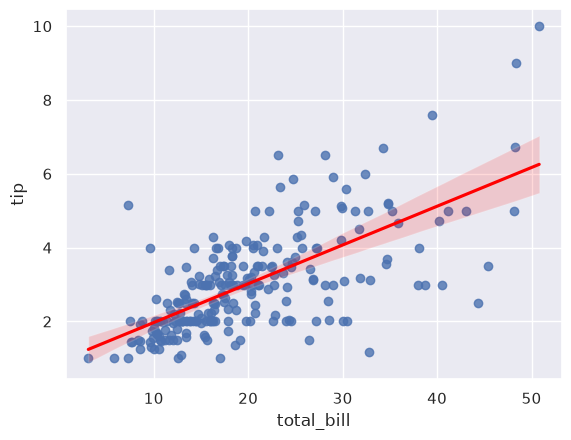

In [35]:
sns.regplot(data=df, x='total_bill', y='tip', line_kws={'color': 'red'})

### Observations:
- **Positive Linear Relationship**: There is a clear, positive linear correlation between `total_bill` and `tip`. As the bill increases, the tip tends to increase as well.
- **Increasing Variance**: The spread of the data points around the regression line is not constant. As `total_bill` grows, the variance (or spread) of the `tip` amount visibly widens (a phenomenon known as heteroscedasticity).

# Goal
To explore gender differences in tipping behavior and bill amounts. We use a scatter plot colored by `sex`, alongside a KDE (Kernel Density Estimation) plot to highlight areas of high data density.

<Axes: xlabel='total_bill', ylabel='tip'>

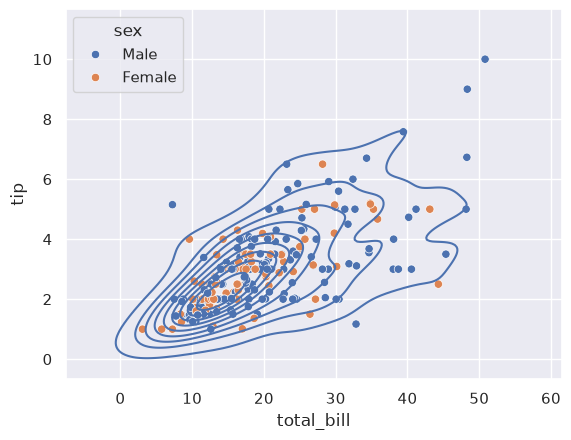

In [36]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
sns.kdeplot(data=df, x='total_bill', y='tip')

### Observations:
- In the denser regions (lower to average bill amounts), the distribution between males and females is somewhat mixed.
- However, as we move further from the median towards higher total bills, the male-to-female ratio widens significantly. Males dominate the high-end outliers for both `total_bill` and `tip`.

# Question:
**While men pay higher bills on average, are they actually more generous when tipping compared to women?**

- By calculating a new feature, `tip_percentage` (`tip / total_bill`), and visualizing its average across genders using a bar plot, we can determine which group is relatively more generous.
- Using a box plot, we can evaluate if any observed differences are solid trends or merely the result of a few extreme outliers.

Text(0.5, 0.98, 'Generousity Plot')

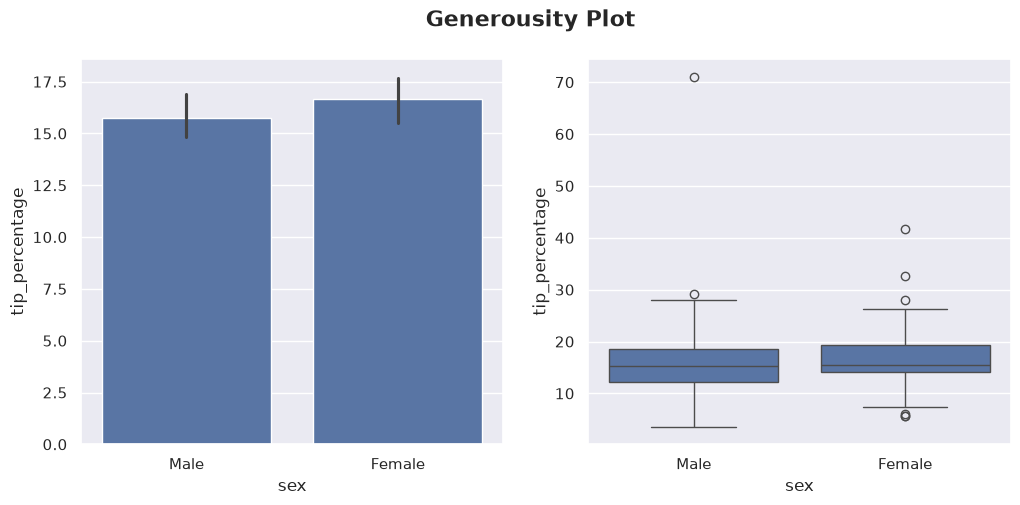

In [37]:
df['tip_percentage'] = df['tip'] / df['total_bill'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, y='tip_percentage', x='sex', ax=ax1)
sns.boxplot(data=df, x='sex', y='tip_percentage', ax=ax2)

fig.suptitle('Generousity Plot', fontsize=16, fontweight='bold')

### Observations:
- The bar plot indicates that the average `tip_percentage` is slightly higher for females than for males.
- However, looking at the box plot, the overall distributions are extremely similar, and the slight difference in averages is very small and likely due to noise or outliers rather than a true underlying pattern.
- **Conclusion**: Gender (`sex`) does not have a meaningful or statistically significant impact on tip percentage. It is not a strong predictor of generosity.

# Question:
**Is the `smoker` feature a good predictor for tip amount?**

- Similar to our gender analysis, we can evaluate the generosity of smokers versus non-smokers by examining their average `tip_percentage`.
- We use a box plot to check if any differences are driven by broader trends or isolated outliers.

<Axes: xlabel='smoker', ylabel='tip_percentage'>

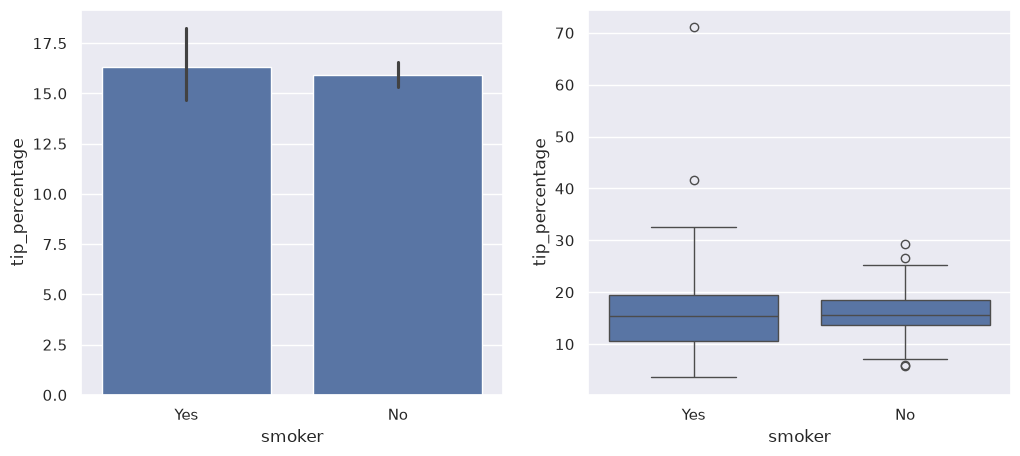

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, y='tip_percentage', x='smoker', ax=ax1)
sns.boxplot(data=df, x='smoker', y='tip_percentage', ax=ax2)

### Observations:
- The average `tip_percentage` is nearly identical between smokers and non-smokers.
- While the bar plot might show a very slight variation, the box plot reveals that smokers have a higher variance, which is primarily driven by a couple of extreme outliers on the high end.
- **Conclusion**: Being a smoker does not significantly affect a person's tip percentage. This feature is unlikely to be a useful predictor.

# Question:
**Does the size of the party directly affect the tip amount, or does it merely drive up the total bill?**

- We can investigate this by comparing the average `total_bill` for each party size against the average `tip` amount.
- Additionally, checking the `tip_percentage` across different party sizes will tell us if larger parties tend to be more or less generous proportionally. If there's a strong trend, `size` might be a valuable feature.

<Axes: xlabel='size', ylabel='tip'>

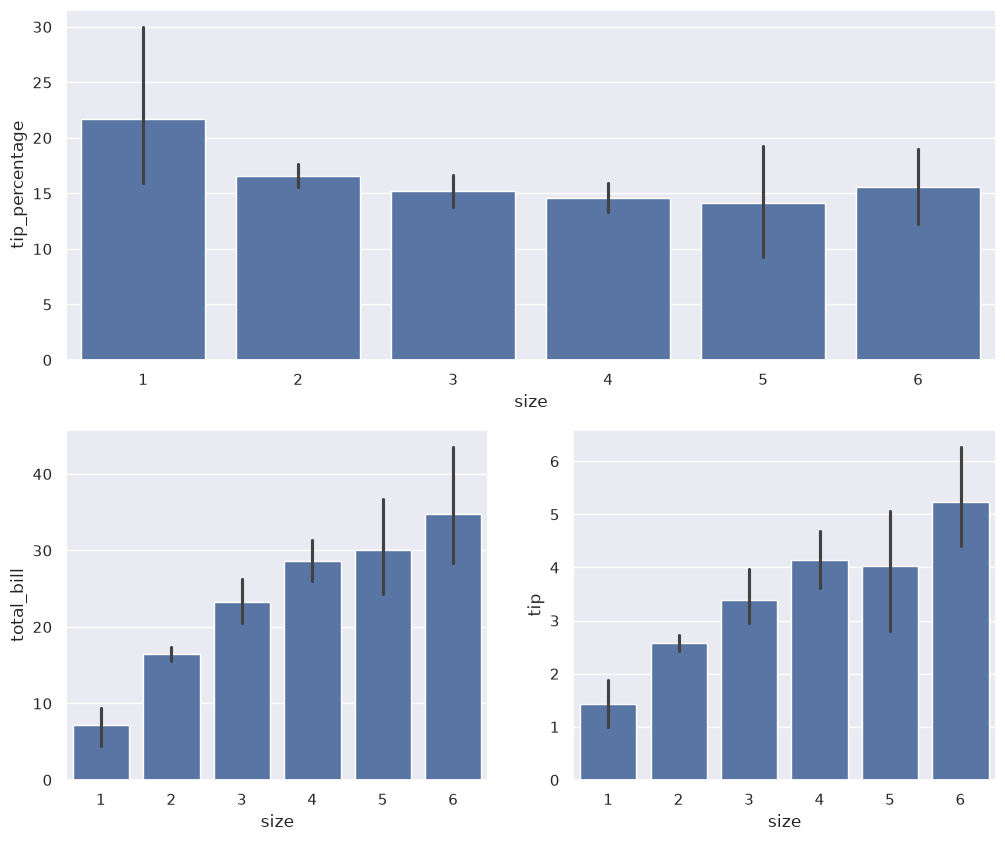

In [39]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

sns.barplot(data=df, y='tip_percentage', x='size', ax=ax1)
sns.barplot(data=df, y='total_bill', x='size', ax=ax2)
sns.barplot(data=df, y='tip', x='size', ax=ax3)

### Observations:
- As expected, the bar plots show that `size` has a strong, predictable effect on the `total_bill`, which in turn increases the absolute `tip` amount.
- However, when looking at `tip_percentage`, there is a mild negative trend for parties of size 2 and larger (larger parties tip a slightly lower percentage). The data for `size=1` is too scarce (n=4) to draw reliable conclusions.
- **Conclusion**: The effect of party size on the tip amount is almost entirely explained by the increase in the total bill. Because `size` mostly just acts as a proxy for `total_bill`, it does not provide much independent predictive power for the tip.

# Question:
**How do day of the week and time of day influence dining habits and tipping behavior?**

Specifically, we want to know:
1. Do party sizes and total bills fluctuate significantly depending on the day or time (Lunch vs. Dinner)?
2. Are diners more generous (higher `tip_percentage`) on weekends or during dinner?

We will answer these questions by comparing `size`, `total_bill`, `tip`, and `tip_percentage` across different days and times.

<Axes: xlabel='time', ylabel='tip_percentage'>

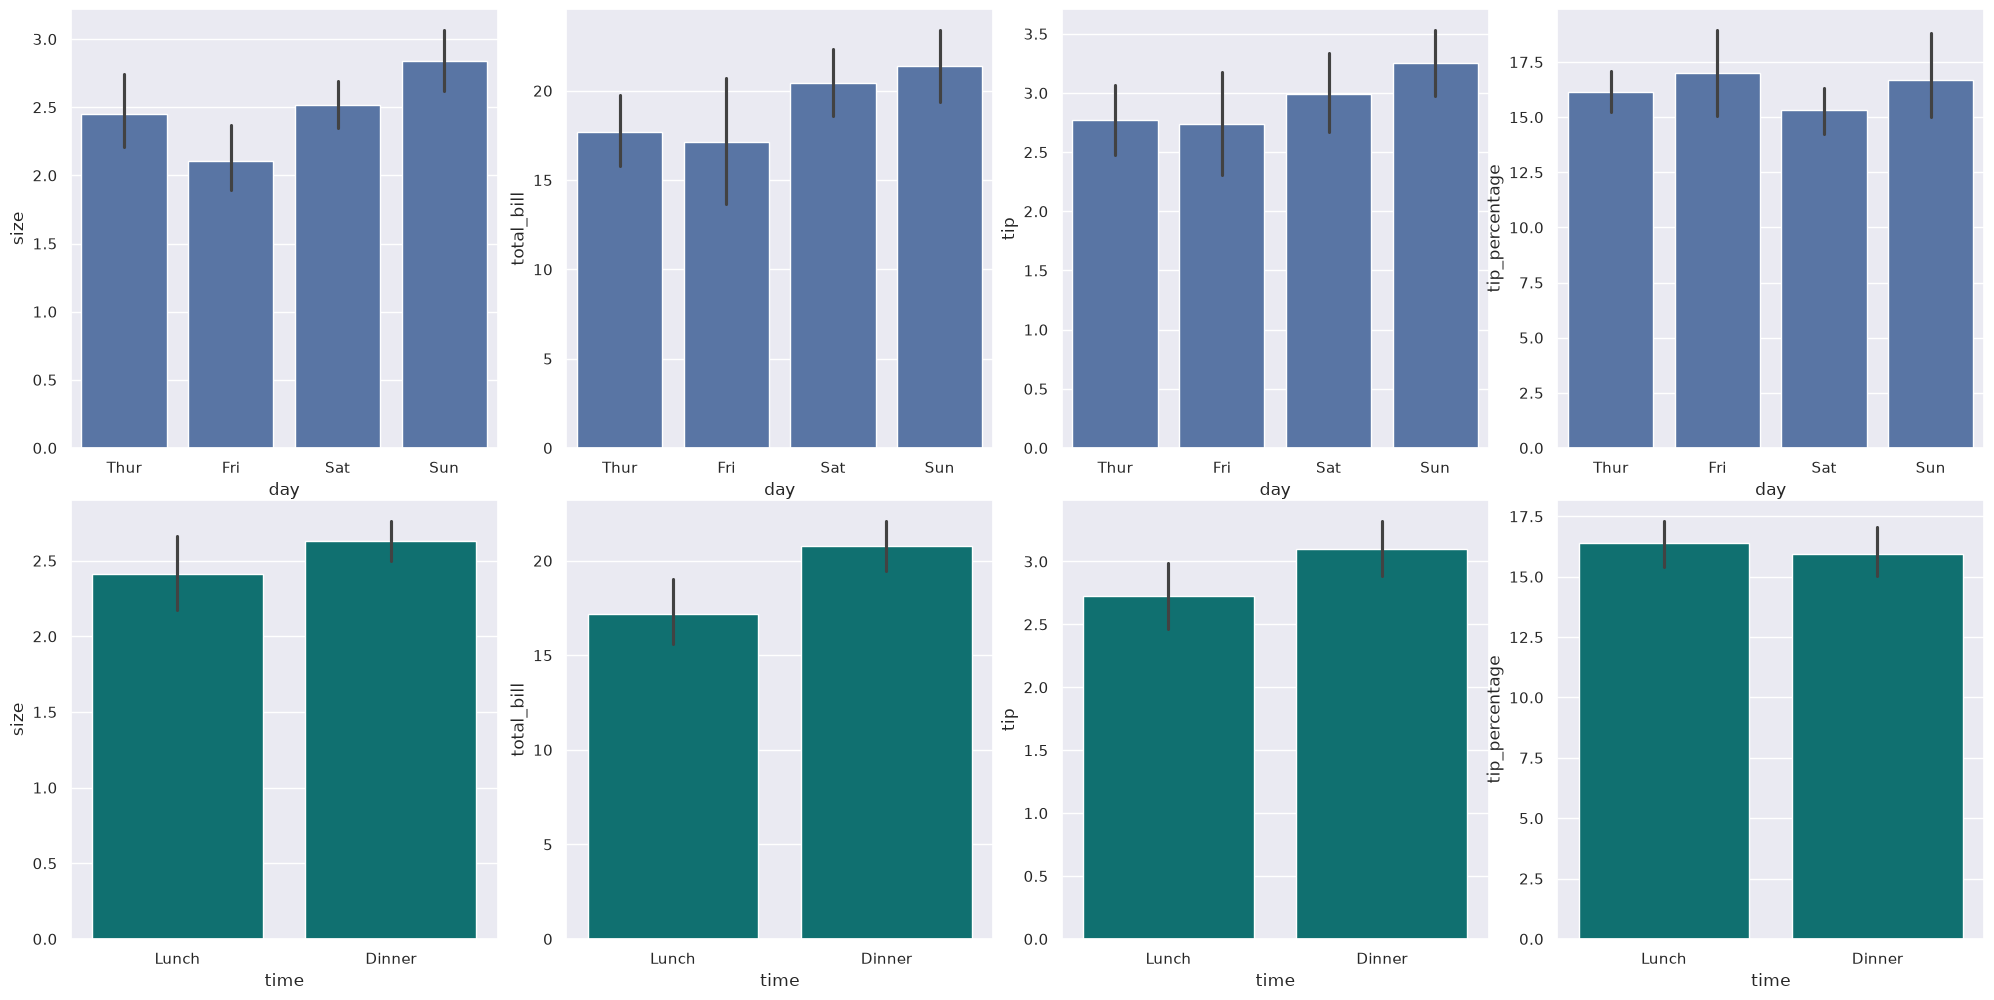

In [40]:
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(20, 10))
fig.tight_layout()

sns.barplot(data=df, x='day', y='size', ax=ax1)
sns.barplot(data=df, x='day', y='total_bill', ax=ax2)
sns.barplot(data=df, x='day', y='tip', ax=ax3)
sns.barplot(data=df, x='day', y='tip_percentage', ax=ax4)

sns.barplot(data=df, x='time', y='size', ax=ax5, color='teal')
sns.barplot(data=df, x='time', y='total_bill', ax=ax6, color='teal')
sns.barplot(data=df, x='time', y='tip', ax=ax7, color='teal')
sns.barplot(data=df, x='time', y='tip_percentage', ax=ax8, color='teal')

### Observations:
- **Size and Bill Trends**: The day of the week and time of day have a mild effect on party size and the total bill (e.g., weekends and dinners see slightly larger parties and higher bills). Because the bills are higher, the absolute `tip` amounts are also higher during these times.
- **Generosity (Tip Percentage)**: The bar plots show that the average `tip_percentage` remains remarkably flat across all days of the week and between lunch and dinner. The minor fluctuations observed are likely just random noise.
- **Conclusion**: The day and time only influence the tip amount indirectly by influencing the total bill. They do not change a person's underlying generosity (`tip_percentage`). Therefore, `day` and `time` are not effective independent predictors for our model; `total_bill` already captures their financial impact. We can safely drop them.

# Goal
To quantify the relationships between all features by calculating a correlation matrix and visualizing it with a heatmap. This will help us identify which features are most strongly correlated with our target (`tip`) and check for multicollinearity among our predictors.

<Axes: >

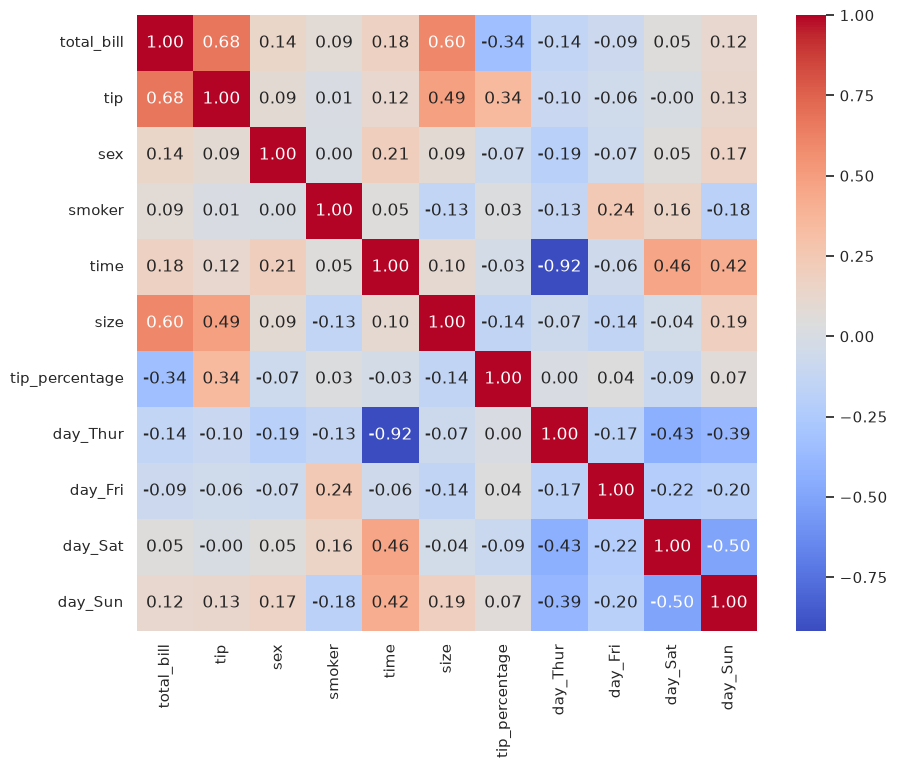

In [41]:
df_modified = df.copy()
df_modified['sex'] = df_modified['sex'].map({'Male': 1, 'Female': 0})
df_modified['smoker'] = df_modified['smoker'].map({'Yes': 1, 'No': 0})
df_modified['time'] = df_modified['time'].map({'Dinner': 1, 'Lunch': 0})
df_modified = pd.get_dummies(df_modified, columns=['day'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_modified.corr(), cmap='coolwarm', annot=True, fmt='.2f', )

### Observations:
- **Strongest Predictor**: As expected, `total_bill` has the highest correlation with our target `tip` (0.68).
- **Multicollinearity**: The `size` feature has a strong correlation (0.60) with `total_bill`. While `size` also has a moderate correlation (0.49) with `tip`, this relationship is largely redundant because the information in `size` is already captured by `total_bill`.
- **Other Features**: The categorical features (sex, smoker, time, day) show very weak correlations with `tip` and with each other.

# Final Conclusion:
Based on our visual analysis and the correlation matrix, `total_bill` is the only strong, reliable predictor of the `tip` amount. The other features either have no significant effect on tipping behavior or their effects are entirely overshadowed by the total bill itself (like `size`, `day`, and `time`).

For a simple and robust linear regression model, we can proceed using **only `total_bill` as our independent variable**.